<a href="https://colab.research.google.com/github/Carlesoler8/carlesoler8.github.io/blob/main/Melfi_recuperacion_DS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Melfi — De los supuestos a la evidencia

**Autor del TFM:** Carles Soler · **Tutor:** Jaime Pineda · Máster en Analítica de Negocios (UNIE)

En este cuaderno vamos a realizar **dos análisis de ciencia de datos** para integrar mi TFM de Melfi los cuales: añaden la pieza que faltaba (datos reales + técnica analítica) y refuerzan lo que el tribunal echó en falta.

- **Bloque 1 — Análisis de reseñas de la competencia.** Descargamos reseñas reales de apps rivales (Google Play) y analizamos **de qué se quejan sus usuarios** → evidencia real.
- **Bloque 2 — Simulación del modelo financiero.** Cogemos el modelo del capítulo 7 y lo probamos contra miles de escenarios para hablar de **probabilidad y riesgo**, no de un solo escenario.

In [2]:
# --- Setup: instala las librerias ---
!pip install -q google-play-scraper scikit-learn pandas matplotlib   # descarga las librerias en Colab

import numpy as np                 # calculo numerico (arrays, numeros aleatorios)
import pandas as pd                # tablas de datos (DataFrame): como un Excel manejado por codigo
import matplotlib.pyplot as plt    # graficos
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS  # texto -> numeros (TF-IDF)
from sklearn.decomposition import NMF                                            # agrupar textos en temas

RANDOM_STATE = 14   # semilla fija -> resultados IGUALES cada vez (reproducibilidad)
print("Librerias listas.")

Librerias listas.


### ⚙️ CONFIG · Competidores y mercados

Definimos tres mercados; cada uno se analiza **por separado** con las palabras de su idioma (no se mezclan idiomas):

- **US/EN** — benchmark internacional (BetterHelp, Talkspace, Wysa).
- **ES/LATAM** — tu mercado objetivo (ifeel, TherapyChat).
- **IT** — Unobravo, que está en tu tabla T6. Es **italiana**: en español apenas tiene reseñas, así que la analizamos en **su** mercado, donde sí hay volumen.

In [4]:
# app_id = lo que va tras 'id=' en la URL de Google Play. Cada mercado lleva su idioma (lang) y pais (country).
MARKETS = {
    "US/EN":    {"lang": "en", "country": "us", "apps": {        # benchmark internacional de categoria
        "BetterHelp":  "com.betterhelp",
        "Talkspace":   "com.talkspace.talkspaceapp",
        "Wysa":        "bot.touchkin"}},
    "ES/LATAM": {"lang": "es", "country": "es", "apps": {        # tu mercado objetivo (resenas en espanol)
        "ifeel":       "com.ifeel.ifeeluserchat",
        "TherapyChat": "com.terapiachat.android"}},
    "IT":       {"lang": "it", "country": "it", "apps": {        # Unobravo (de tu T6): italiana -> aqui tiene volumen
        "Unobravo":    "com.unobravo.patient"}},
}
COUNT_PER_APP = 400   # cuantas resenas pedimos por app (las mas recientes)
# ====================================================================================================

---
# Bloque 1 — Análisis de reseñas de la competencia

**Análisis que aporta:** *Metodología* + *Estado del arte* con **datos reales** y voz de cliente para tus hipótesis de **precio** y de **cómo elige el cliente**.

**Técnicas:**
- **Web scraping** — descargar datos públicos de una web con código ([librería](https://github.com/JoMingyu/google-play-scraper)).
- **Análisis de sentimiento** — clasificar un texto como positivo/negativo. Usamos la **estrella** (1–5) como etiqueta.
- **TF-IDF** — qué palabras **caracterizan** a un grupo de textos ([doc](https://scikit-learn.org/stable/modules/feature_extraction.html#tfidf-term-weighting)).
- **Modelado de temas (NMF)** — agrupa muchos textos en sus **temas** principales ([doc](https://scikit-learn.org/stable/modules/decomposition.html#non-negative-matrix-factorization-nmf)).

### 1.1 · Bajar las reseñas

Definimos la función que baja reseñas y la ejecutamos para los tres mercados.

In [5]:
from google_play_scraper import reviews, Sort   # reviews() baja resenas; Sort.NEWEST = ordenar por fecha

def fetch_market(market, lang, country, apps, count):
    rows = []                                      # acumulamos una fila por resena
    for name, app_id in apps.items():              # recorremos cada app del mercado
        res, _ = reviews(app_id, lang=lang, country=country, sort=Sort.NEWEST, count=count)  # baja 'count' resenas
        for r in res:                              # cada r = una resena (dict: score, content, fecha...)
            if r.get("content"):                   # solo las que tienen texto
                rows.append({"market": market, "app": name,
                             "score": r["score"],      # score = estrellas (1-5)
                             "content": r["content"]})  # content = texto
        print(f"  {name:<12} {len([x for x in res if x.get('content')]):>4} resenas")
    return pd.DataFrame(rows)                       # tabla con las resenas del mercado

In [6]:
# Ejecutamos la captura para los 3 mercados y los juntamos en una sola tabla 'df'
frames = [fetch_market(m, c["lang"], c["country"], c["apps"], COUNT_PER_APP) for m, c in MARKETS.items()]
df = pd.concat(frames, ignore_index=True)          # pegamos las tablas una debajo de otra
print(f"\nTOTAL: {len(df)} resenas reales de {df.app.nunique()} apps")
df.head()                                          # primeras 5 filas, para echar un ojo a los datos

  BetterHelp    400 resenas
  Talkspace     400 resenas
  Wysa          400 resenas
  ifeel         400 resenas
  TherapyChat   400 resenas
  Unobravo      400 resenas

TOTAL: 2400 resenas reales de 6 apps


,market,app,score,content
0,US/EN,BetterHelp,3,Therapist was cool...just...didn't connect rea...
1,US/EN,BetterHelp,1,doesn't give me a chance to explore options be...
2,US/EN,BetterHelp,1,haven't used their services in 6 months and st...
3,US/EN,BetterHelp,5,"Excellent services, very thankful."
4,US/EN,BetterHelp,2,they take my insurance so thats a plus but aft...


### 1.2 · Sentimiento desde la estrella

**1–2 = negativo · 3 = neutral · 4–5 = positivo.** Las **negativas** son la mina: ahí está lo que falla en la competencia.

In [7]:
# pd.cut reparte cada 'score' (1-5) en tres cajones segun los cortes [0,2,3,5]
df["sentiment"] = pd.cut(df.score, [0, 2, 3, 5], labels=["negativo", "neutral", "positivo"])
# % de cada sentimiento por app (proporciones que suman 1)
print(df.groupby("app", observed=True).sentiment.value_counts(normalize=True).round(2))

app          sentiment
BetterHelp   negativo     0.51
             positivo     0.44
             neutral      0.05
Talkspace    negativo     0.59
             positivo     0.35
             neutral      0.06
TherapyChat  positivo     0.83
             negativo     0.16
             neutral      0.02
Unobravo     positivo     0.72
             negativo     0.22
             neutral      0.06
Wysa         positivo     0.70
             negativo     0.26
             neutral      0.04
ifeel        positivo     0.60
             negativo     0.36
             neutral      0.04
Name: proportion, dtype: float64


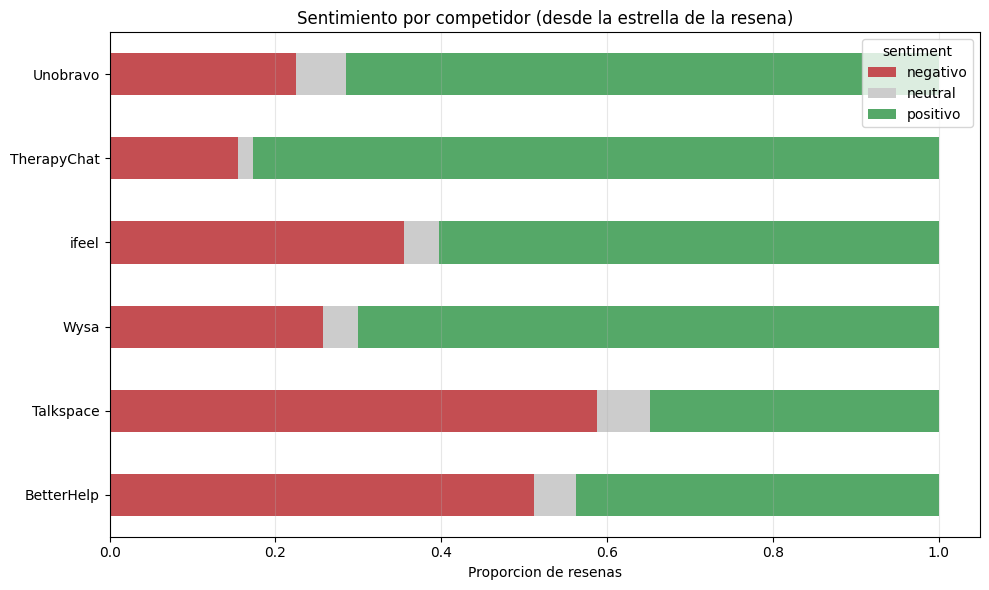

In [8]:
# Figura: % de neg/neu/pos por app (barra horizontal apilada)
order = [a for c in MARKETS.values() for a in c["apps"]]      # orden de apps = el de la CONFIG
ct = pd.crosstab(df.app, df.sentiment, normalize="index").reindex(order)[["negativo","neutral","positivo"]]
ax = ct.plot(kind="barh", stacked=True, figsize=(10, 6), color=["#C44E52", "#CCCCCC", "#55A868"])  # rojo/gris/verde
ax.set_title("Sentimiento por competidor (desde la estrella de la resena)")
ax.set_xlabel("Proporcion de resenas"); ax.set_ylabel("")
ax.grid(True, axis="x", alpha=0.3); plt.tight_layout(); plt.show()

### 1.3 · ¿De qué se quejan? — TF-IDF + temas (NMF)

Configuramos la lógica en tres pasos: **(a)** configurar qué palabras ignorar, **(b)** definir la herramienta, **(c)** aplicarla mercado a mercado.

In [9]:
# --- 1.3a · CONFIG: palabras a IGNORAR (vacias por idioma + de dominio) ---
# Sin esto, 'the/de/di' y 'app/terapeuta' tapan las quejas reales.
SPANISH_STOP = set(("a al algo algunas algunos ante antes como con contra cual cuando de del desde donde dos el ella "
 "ellas ellos en entre era eran es esa esas ese eso esos esta estaba estan estar este esto estos ha habia han hasta hay "
 "la las le les lo los mas me mi mis mucho muy nada ni no nos o os otra otras otro otros para pero poco por porque que se "
 "sea si sin sobre solo son su sus tan te tiene tienen toda todas todo todos tu tus un una uno unos y ya estoy estas "
 "siempre nunca cosa cosas tener aqui ahi aun asi sino tambien tras durante segun aunque mientras").split())
ITALIAN_STOP = set(("a ad al allo ai agli alla alle con col coi da dal dallo dai dagli dalla dalle di del dello dei degli "
 "della delle in nel nello nei negli nella nelle su sul sullo sui sugli sulla sulle per tra fra il lo la i gli le un uno "
 "una e che non si ma se come piu poco tutto tutti ho ha hanno sono essere fare questo questa questi queste mi ti ci vi "
 "loro suo sua anche solo dopo prima quando dove perche ce non c").split())

# Palabras de DOMINIO (en/es/it): salen en TODAS las resenas del sector y no discriminan -> fuera
DOMAIN_STOP = {"therapist","therapy","app","apps","session","sessions","help","just","like","dont","doesn","didnt",
 "psychologist","talk","people","good","great","love","time","day","use","really","im","ive",
 "psicologo","psicologos","terapeuta","terapia","aplicacion","sesion","sesiones","ayuda","persona","gente","bien","bueno",
 "buena","gusta","muy","solo","vez","dia","hora","hace","hacer","puede","super","genial","excelente","recomiendo",
 "psicologa","terapeuta","seduta","seduto","applicazione","sessione","aiuto","persona","ottimo","consiglio","molto"}

def stopwords_for(lang):                              # devuelve la lista de palabras a ignorar segun el idioma
    base = {"en": ENGLISH_STOP_WORDS, "es": SPANISH_STOP, "it": ITALIAN_STOP}[lang]
    return list(set(base) | DOMAIN_STOP)
print("Listas de stop-words listas (en / es / it + dominio).")

Listas de stop-words listas (en / es / it + dominio).


In [10]:
# --- 1.3b · La herramienta: para UN mercado, saca los temas de queja (TF-IDF -> NMF) ---
def themes_for_market(sub, lang, k=4, n_terms=9):
    neg = sub[(sub.sentiment == "negativo") & (sub.content.str.len() > 15)]   # solo negativas con texto
    # TF-IDF: texto -> numeros, dando mas peso a las palabras caracteristicas de las quejas
    vec = TfidfVectorizer(ngram_range=(1, 2),         # palabras sueltas y pares de palabras
                          stop_words=stopwords_for(lang),  # ignora las palabras de la celda 1.3a (segun idioma)
                          min_df=4, max_df=0.5,        # fuera lo muy raro (<4 resenas) y lo demasiado comun (>50%)
                          strip_accents="unicode",     # 'sesion' y 'sesión' cuentan igual
                          token_pattern=r"(?u)\b[^\W\d_]{3,}\b")  # solo palabras de 3+ letras (sin numeros)
    X = vec.fit_transform(neg.content)                # X = matriz (resenas x palabras) con pesos TF-IDF
    terms = np.array(vec.get_feature_names_out())     # palabras aprendidas
    nmf = NMF(n_components=k, random_state=RANDOM_STATE, init="nndsvda", max_iter=500)  # k temas
    W = nmf.fit_transform(X)                           # W = cuanto pertenece cada resena a cada tema
    H = nmf.components_                                 # H = cuanto pesa cada palabra en cada tema
    share = pd.Series(W.argmax(axis=1)).value_counts(normalize=True)  # % de resenas en cada tema
    print(f"  {len(neg)} resenas negativas | {k} temas:")
    topics = {}
    for t in range(k):
        words = list(terms[H[t].argsort()[::-1][:n_terms]])  # las palabras de mas peso del tema
        topics[t] = words
        print(f"   Tema {t} ({share.get(t,0):4.0%}): {', '.join(words)}")
    return topics
print("Herramienta lista. La aplicamos mercado a mercado en la siguiente celda.")

Herramienta lista. La aplicamos mercado a mercado en la siguiente celda.


In [11]:
# --- 1.3c · Aplicar la herramienta a CADA mercado por separado ---
topics_by_market = {}
for m, cfg in MARKETS.items():
    print(f"\n=== {m} ===")
    topics_by_market[m] = themes_for_market(df[df.market == m], cfg["lang"])


=== US/EN ===
  525 resenas negativas | 4 temas:
   Tema 0 ( 61%): money, therapists, week, didn, free, pay, got, need, charged
   Tema 1 ( 14%): insurance, don, subscription, accept, cover, payment, information, covered, talkspace
   Tema 2 ( 13%): service, customer, customer service, terrible, billing, support, buggy, worst, customer support
   Tema 3 ( 12%): update, open, won, screen, telling, keeps, missed, white screen, white

=== ES/LATAM ===
  187 resenas negativas | 4 temas:
   Tema 0 ( 22%): dinero, tienes, quieren, mala, siquiera, tiempo, nadie, verdad, mal
   Tema 1 ( 16%): pagar, gratis, tienes, hablar, realmente, consulta, pense, opcion, servicio
   Tema 2 (  9%): edad, menores, menores edad, menor, menor edad, pueden, padres, dar, soy
   Tema 3 ( 52%): puedo, deja, dice, cuenta, problema, tengo, iniciar, funciona, despues

=== IT ===
  88 resenas negativas | 4 temas:
   Tema 0 ( 56%): all, appuntamento, volta, ogni, dell, primo, assolutamente, chi, pagamento
   Tema 1 ( 

### 1.4 · De la queja del competidor a la palanca de Melfi


In [12]:
# Reglas: (palabras_pista, nombre_de_la_brecha, respuesta_de_Melfi). Incluyen pistas en EN / ES / IT.
GAP_RULES = [
 (["expensive","cost","money","price","afford","subscription","caro","precio","pagar","cobran","dinero","gratis",
   "reembolso","prezzo","costoso","abbonamento","soldi","rimborso","pagare","costa"],
  "Precio", "Arbitraje LATAM: ~25 EUR/sesion vs 45-65 EUR de la competencia"),
 (["match","choose","switch","fit","random","assigned","elegir","asignan","cambiar","afinidad","scegliere","cambiare"],
  "Asignacion", "Asignacion por afinidad (sin paralisis de eleccion)"),
 (["wait","booking","book","availability","appointment","espera","cita","agendar","reservar","tarda","demora",
   "appuntamento","attesa","prenotare","disponibilita","aspettare"],
  "Inmediatez", "Slots reales el mismo dia (on-demand)"),
 (["rushed","short","late","cancel","unprofessional","corto","tarde","cancelan","manipularon","pesimos","experiencia",
   "scadente","pessimo","professionale"],
  "Calidad/vetting", "Vetting de psicologos + valoracion post-sesion"),
 (["crash","buggy","login","glitch","update","screen","falla","error","cuelga","lenta","entrar","iniciar","cuenta",
   "correo","errore","accedere","account","bloccato","aggiornamento"],
  "Tecnico/UX", "Infra estable + prototipo cuidado (landing en anexo)"),
]
for m, topics in topics_by_market.items():
    print(f"\n[{m}]  brecha del competidor -> respuesta de Melfi")
    seen = set()
    for t, words in topics.items():
        blob = " ".join(words)                          # palabras del tema juntas en un texto
        best = max(GAP_RULES, key=lambda r: sum(w in blob for w in r[0]))  # la regla con mas pistas coincidentes
        if sum(w in blob for w in best[0]) and best[1] not in seen:
            print(f"   {best[1]:<14} <- {', '.join(words[:4])}")
            print(f"   {'':14}    Melfi: {best[2]}")
            seen.add(best[1])


[US/EN]  brecha del competidor -> respuesta de Melfi
   Precio         <- money, therapists, week, didn
                     Melfi: Arbitraje LATAM: ~25 EUR/sesion vs 45-65 EUR de la competencia
   Tecnico/UX     <- service, customer, customer service, terrible
                     Melfi: Infra estable + prototipo cuidado (landing en anexo)

[ES/LATAM]  brecha del competidor -> respuesta de Melfi
   Precio         <- dinero, tienes, quieren, mala
                     Melfi: Arbitraje LATAM: ~25 EUR/sesion vs 45-65 EUR de la competencia
   Tecnico/UX     <- puedo, deja, dice, cuenta
                     Melfi: Infra estable + prototipo cuidado (landing en anexo)

[IT]  brecha del competidor -> respuesta de Melfi
   Inmediatez     <- all, appuntamento, volta, ogni
                     Melfi: Slots reales el mismo dia (on-demand)
   Precio         <- pessima, esperienza, soldi, assistenza
                     Melfi: Arbitraje LATAM: ~25 EUR/sesion vs 45-65 EUR de la competencia


In [14]:
# Para que salgan las reseñas completas
import pandas as pd
pd.set_option('display.max_colwidth', None)
df.to_csv("reseñas_melfi.csv")

In [15]:
df[(df.app=="ifeel") & (df.sentiment=="negativo")].content.sample(15)

,content
1273,"Jamás recomendaría esta aplicación a nadie. Si de verdad necesitas ayuda, acude a una terapia presencial. Éstos solo quieren sacarte el dinero. Te enviaran un mensaje al día y darán vueltas y vueltas para no centrarse en tu consulta y se irán por las ramas con la finalidad de mantenerte el máximo tiempo posible y seguir pagando cada mes. Una auténtica pérdida de tiempo y de dinero."
1476,"En un mes me han atendido 20 minutos. Yo creo que es un timo. Dicen que me han llamado, pero yo tengo el teléfono en la mano. Repito en un mes 20 minutos."
1260,No me gusto por k pense k ayudaban gratis y no es asi eso debe desirlo antes de rejiatrarte
1224,"Excelente app y psicólogos! Lo malo es que no me permite registrar cómo me siento, siempre que le doy a esa opción (para el journaling) me marca que hay un error en la conexión a Internet. Hace falta una actualización como hot fix"
1405,"Mucha promocion para conseguir plata, nada de servicio gratis. Pura estafa"
1408,"Me han asignado a un terapeuta psicólogo y me está viniendo fenomenal. Para todo. He mejorado en seguridad en autoestima y sobre todo en tranquilidad y paz. Considero que es un dinero muy bien invertido porque la salud mental es lo primero y tener un profesional que te acompañe todos los días es todo un lujo. Me calma, me controla la ansiedad y me siento protegido y me ahorro tener que ir a una consulta, porque es mucho más cómodo y personalizado. Me siento feliz con mi terapeuta. Gracias Angel"
1234,"La asesoría es paga, por lo tanto la aplicación también."
1320,La peor aplicación que he visto en toda mi vida. Para empezar no le hacéis terapia a menores y si han tocado el suicidio mucho menos. Por vuestra culpa muchas muertes se podrían haber evitado.
1266,"Me aparece problema en la conexión, no me deja hacer nada y mi conexión celular esta lo más normal"
1401,"Se supone que es gratis y tienes que pagar es publicidad engañosa, un timo."


In [16]:
df[(df.app=="TherapyChat") & (df.sentiment=="negativo")].content.sample(15)

,content
1776,"Intento hacerme cuenta y me dice que me manda un codigo al correo electrónico y ya puedo esperar a ver si en algún año llega, horror, desisntalando"
1805,"Hablas con bot de entrada, te asignan un psicólogo que no puede atenderte antes de la semana gratuita. Cambias de terapeuta y no te asignan ninguno más.... Si solo empezar funciona así, que tipo de confianza inspira para gestionar tus problemas?"
1996,"El chat es horrible, tiene bugs al escribir, no se envia correctamente o no se envia. Al redactar el texto se borra si sales de la pantalla. En videollamada se corta si sales de la aplicacion, no puedes hacer nada en segundo plano como leer notas apuntadas en agenda o evernote"
1829,"Cambio la calificación anterior. Las dos terapeutas que me han tocado están muy preparadas, muy atentas, te dan un plan de trabajo personalizado, desde las primeras sesiones sentí la diferencia, que lástima que tenga tantas fallas en el sistema, no llegan notificaciones, las llamadas se caen aunque haya buen internet, los cobros se hacen dobles, se cancela la suscripción sin motivo alguno, me he tenido que quedar sin terapia por varias semanas por estos detalles. Ojalá mejoren."
1844,No sirve
1607,"Pésima atención al paciente por parte de la plataforma (las psicólogas son geniales), cobros de más, errores ""poco frecuentes"" según ellos."
1806,Con chatgpt quién necesita pagar para esto???? Gratis pero paga un plan si
1907,No me atiende .. porque mejor no me ajenda?
1767,Pagando salud mental pagando quieres ayuda pagando en fin
1799,"1. Veo la app y todo el marketing 2. Veo las queasy de un sistema que ko funciona. 3. Instalo la app y no me deja registrarme, sale un bug.... Se necesita de una mejor inversion en vuestro sistema, no sirve de nada la idea si la app no funciona..."


---
# Bloque 2 — Simulación de tu modelo financiero (Monte Carlo)

**Aporta:** *Metodología* cuantitativa y refuerza el *plan financiero* (cap. 7).

**Monte Carlo:** en vez de **un** número por supuesto, metes un **rango** y el ordenador prueba miles de combinaciones. Se obtiene la **distribución** de resultados → vemos la **probabilidad** de ser rentable y el **riesgo** de no serlo
([referencia](https://en.wikipedia.org/wiki/Monte_Carlo_method)).

### 2.1 · Modelo de supuestos + validación

Dos pasos: **(a)** supuestos, **(b)** la fórmula del margen, **(c)** comprobacion que es lo que hay en la memoria.

In [19]:
# --- 2.1a · CONFIG: tus supuestos como (minimo, valor_central, maximo). Se usan como RANGO al simular ---
CFG = {
    "sessions_month":   (700, 1650, 2600),    # sesiones/mes: tu escenario pesimista / base / optimista (T11)
    "price_b2c":        (20, 25, 30),          # precio por sesion al cliente final (T10)
    "pay_psychologist": (10, 12, 14),          # lo que cobra el psicologo por sesion (T10)
    "op_cost_session":  (1.5, 2.0, 3.0),       # coste operativo por sesion (T10)
    "b2b2c_commission": (0.10, 0.15, 0.20),    # comision del canal empresa B2B2C (T10)
    "premium_month":    (60, 70, 80),          # precio del plan Premium/mes, incluye 3 sesiones (T10)
    "fixed_cost":       (6000, 7000, 9000),    # costes fijos al mes (T11)
}
MIX_BASE = np.array([0.25, 0.45, 0.30])    # % de sesiones por linea de negocio: B2C / B2B2C / Premium

In [20]:
# --- 2.1b · La formula: margen de contribucion por sesion, mezclando las tres lineas segun su peso ---
def blended_margin(price, pay, op, comm, prem, mix):
    m_b2c   = price - pay - op                       # B2C    = precio - pago psicologo - coste operativo
    m_b2b2c = price * (1 - comm) - pay - op           # B2B2C  = el canal se queda una comision sobre el precio
    m_prem  = prem / 3 - pay - op                     # Premium= 70 EUR / 3 sesiones = precio efectivo por sesion
    mix = np.asarray(mix)
    if mix.ndim == 1:                                 # 1 escenario: mix es un vector de 3 pesos
        return mix[0]*m_b2c + mix[1]*m_b2b2c + mix[2]*m_prem
    return mix[:,0]*m_b2c + mix[:,1]*m_b2b2c + mix[:,2]*m_prem   # miles de escenarios a la vez

In [21]:
# --- 2.1c · Validacion: con el valor CENTRAL de cada supuesto ---
mode = {k: v[1] for k, v in CFG.items()}             # valor central (posicion 1) de cada rango
m_blended = blended_margin(mode["price_b2c"], mode["pay_psychologist"], mode["op_cost_session"],
                           mode["b2b2c_commission"], mode["premium_month"], MIX_BASE)
breakeven = mode["fixed_cost"] / m_blended            # sesiones para cubrir costes = costes fijos / margen
print(f"Margen mezclado : {m_blended:.2f} EUR/sesion   (tu memoria: 8,81)")
print(f"Break-even      : {breakeven:.0f} sesiones/mes  (tu memoria: ~795)")
for name, ses, ref in [("Pesimista",700,-831),("Base",1650,7541),("Optimista",2600,15912)]:
    eb = m_blended*ses - mode["fixed_cost"]           # EBITDA = margen * sesiones - costes fijos
    print(f"  {name:<10} {ses:>5} ses -> EBITDA {eb:>8.0f} EUR   (memoria: {ref})")

Margen mezclado : 8.81 EUR/sesion   (tu memoria: 8,81)
Break-even      : 794 sesiones/mes  (tu memoria: ~795)
  Pesimista    700 ses -> EBITDA     -831 EUR   (memoria: -831)
  Base        1650 ses -> EBITDA     7541 EUR   (memoria: 7541)
  Optimista   2600 ses -> EBITDA    15912 EUR   (memoria: 15912)


### 2.2 · La simulación (10.000 escenarios)

Cada supuesto pasa a ser una **distribución triangular** (más peso en la moda). Dos pasos: **(a)** simular y medir probabilidad de beneficio, **(b)** ver la distribución y qué palanca pesa más.

In [22]:
# --- 2.2a · Simular 10.000 escenarios y medir probabilidad de beneficio ---
N = 10_000                                     # numero de escenarios
rng = np.random.default_rng(RANDOM_STATE)      # generador aleatorio con semilla fija (reproducible)
# triangular(min, moda, max): mas probable cerca del centro, menos en los extremos
s = {k: rng.triangular(*v, N) for k, v in CFG.items()}
mix = rng.dirichlet(MIX_BASE * 60, N)          # N mezclas de lineas distintas alrededor de MIX_BASE
margin = blended_margin(s["price_b2c"], s["pay_psychologist"], s["op_cost_session"],
                        s["b2b2c_commission"], s["premium_month"], mix)   # margen de cada escenario
ebitda_m = margin * s["sessions_month"] - s["fixed_cost"]   # EBITDA mensual de cada escenario
be = s["fixed_cost"] / margin                  # sesiones para break-even en cada escenario

print(f"P(EBITDA mensual > 0) = {(ebitda_m > 0).mean():.0%}")   # % de escenarios con beneficio
be5, be50, be95 = np.percentile(be, [5, 50, 95])                # percentiles 5/50/95 del break-even
print(f"Sesiones/mes para break-even -> mediana {be50:,.0f} (rango {be5:,.0f}-{be95:,.0f})")
print(f"Tu escenario base asume {CFG['sessions_month'][1]:,} -> {CFG['sessions_month'][1]/be50:.1f}x el break-even")

P(EBITDA mensual > 0) = 96%
Sesiones/mes para break-even -> mediana 847 (rango 618-1,268)
Tu escenario base asume 1,650 -> 1.9x el break-even


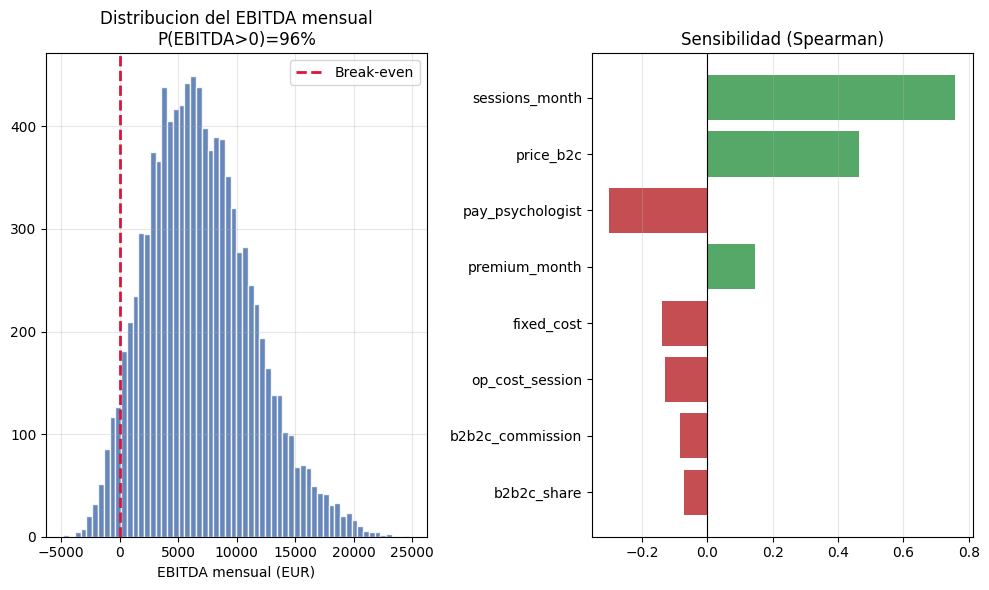

sessions_month      0.76
price_b2c           0.47
pay_psychologist   -0.30
premium_month       0.15
fixed_cost         -0.14
op_cost_session    -0.13
b2b2c_commission   -0.08
b2b2c_share        -0.07
Name: ebitda_m, dtype: float64


In [23]:
# --- 2.2b · Ver la distribucion y la sensibilidad (que palanca mueve mas el EBITDA) ---
sim = pd.DataFrame(s); sim["b2b2c_share"] = mix[:,1]; sim["ebitda_m"] = ebitda_m   # tabla supuestos + EBITDA
corr = sim.corr(method="spearman")["ebitda_m"].drop("ebitda_m")    # correlacion de cada supuesto con el EBITDA
corr = corr.reindex(corr.abs().sort_values(ascending=False).index) # ordenar por importancia (valor absoluto)

fig, axes = plt.subplots(1, 2, figsize=(10, 6))   # dos graficos lado a lado
# Izquierda: histograma = como se reparten los 10.000 EBITDA posibles
axes[0].hist(ebitda_m, bins=60, color="#4C72B0", edgecolor="white", alpha=.85)
axes[0].axvline(0, color="crimson", ls="--", lw=2, label="Break-even")   # linea en EBITDA = 0
axes[0].set_title(f"Distribucion del EBITDA mensual\nP(EBITDA>0)={(ebitda_m>0).mean():.0%}")
axes[0].set_xlabel("EBITDA mensual (EUR)"); axes[0].legend(); axes[0].grid(True, alpha=.3)
# Derecha: barras = sensibilidad (rojo baja el EBITDA, verde lo sube)
axes[1].barh(corr.index[::-1], corr.values[::-1], color=["#C44E52" if v < 0 else "#55A868" for v in corr.values[::-1]])
axes[1].axvline(0, color="black", lw=.8); axes[1].set_title("Sensibilidad (Spearman)"); axes[1].grid(True, axis="x", alpha=.3)
plt.tight_layout(); plt.show()
print(corr.round(2))                              # tabla de correlaciones ordenada por importancia